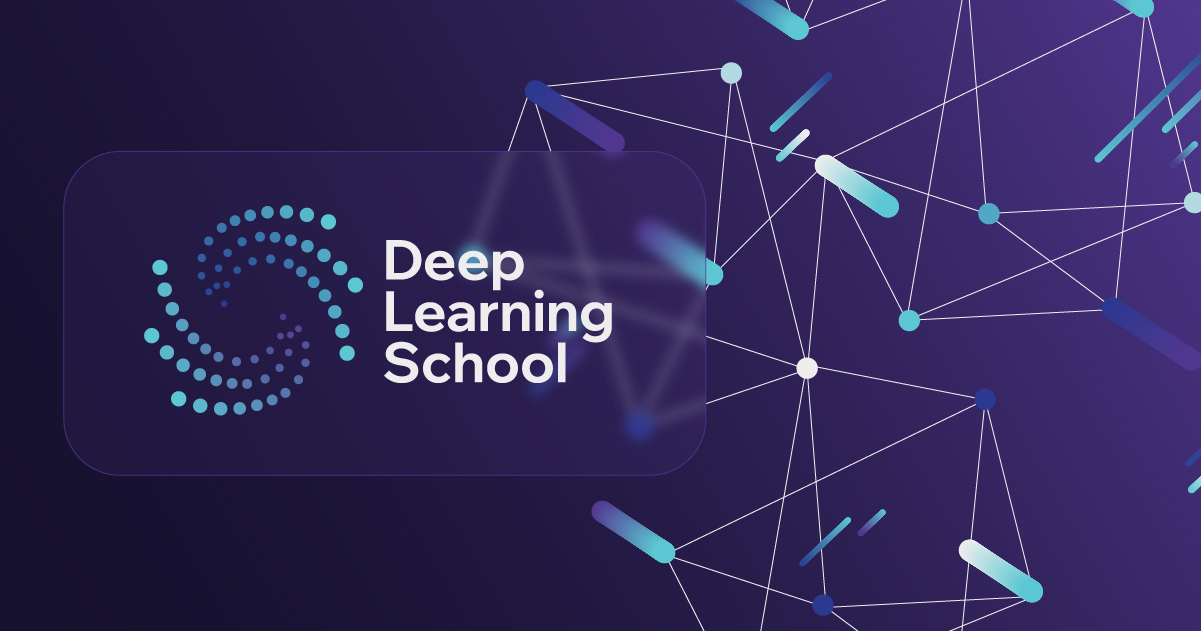

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Полносвязные и свёрточные нейронные сети</b></h1>



В этом занятии вам предстоит потренироваться построению нейронных сетей с помощью библиотеки Pytorch. Делать мы это будем на нескольких датасетах.








In [1]:
import random

import numpy as np
import seaborn as sns
import torch
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader

sns.set(style="darkgrid", font_scale=1.4)

In [2]:
# Reduce stochasticity

SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

In [3]:
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

# Часть 1. Датасет moons

Давайте сгенерируем датасет и посмотрим на него!

In [96]:
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)

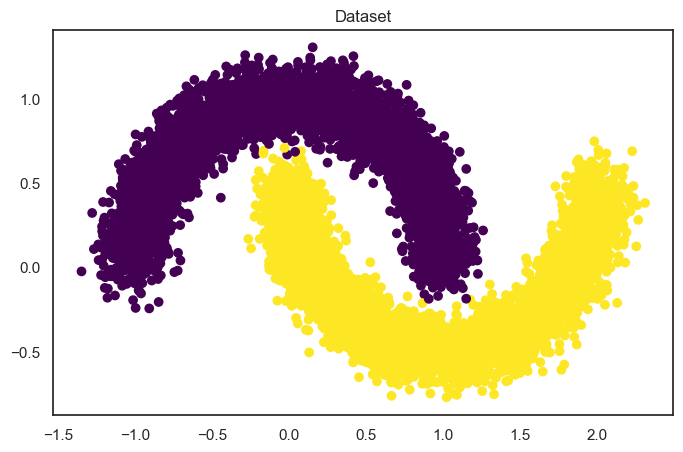

In [97]:
plt.figure(figsize=(8, 5))
plt.title("Dataset")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.show()

Сделаем train/test split

In [81]:
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

### Загрузка данных
В PyTorch загрузка данных как правило происходит налету (иногда датасеты не помещаются в оперативную память). Для этого используются две сущности `Dataset` и `DataLoader`.

1.   `Dataset` загружает каждый объект по отдельности.

2.   `DataLoader` группирует объекты из `Dataset` в батчи.

Так как наш датасет достаточно маленький мы будем использовать `TensorDataset`. Все, что нам нужно, это перевести из массива numpy в тензор с типом `torch.float32`.

### Задание 1. Создайте тензоры с обучающими и тестовыми данными

In [82]:
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)

Создаем `Dataset` и `DataLoader`.

In [83]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_dataloader = DataLoader(train_dataset, batch_size=128)
val_dataloader = DataLoader(val_dataset, batch_size=128)

In [84]:
def dataloader_info(dataloader: DataLoader):
    '''
    Выводит информацию о DataLoader
    :param dataloader:
    :return:
    '''
    global num_samples, batch, _
    num_samples = len(dataloader.dataset)
    print(f"Количество элементов в наборе данных: {num_samples}")
    batch_size = dataloader.batch_size
    print(f"Размер батча: {batch_size}")
    # Размерность данных и типы данных
    for batch in dataloader:
        inputs, labels = batch
        print(f"Размерность входных данных в батче: {inputs.shape}")
        print(f"Размерность меток в батче: {labels.shape}")
        print(f"Тип входных данных: {inputs.dtype}")
        print(f"Тип меток: {labels.dtype}")
        break
    # Уникальные значения меток
    unique_labels = set()
    for batch in dataloader:
        _, labels = batch
        labels_flat = labels.flatten().tolist()
        unique_labels.update(labels_flat)
    print(f"Уникальные значения меток: {unique_labels}")
    num_batches = (num_samples + batch_size - 1) // batch_size
    print(f"Количество батчей: {num_batches}")


In [85]:

dataloader_info(train_dataloader)

Количество элементов в наборе данных: 7500
Размер батча: 128
Размерность входных данных в батче: torch.Size([128, 2])
Размерность меток в батче: torch.Size([128, 1])
Тип входных данных: torch.float32
Тип меток: torch.float32
Уникальные значения меток: {0.0, 1.0}
Количество батчей: 59


## Logistic regression is my profession

**Напоминание**
Давайте вспоним, что происходит в логистической регрессии. На входе у нас есть матрица объект-признак X и столбец-вектор $y$ – метки из $\{0, 1\}$ для каждого объекта. Мы хотим найти такую матрицу весов $W$ и смещение $b$ (bias), что наша модель $XW + b$ будет каким-то образом предсказывать класс объекта. Как видно на выходе наша модель может выдавать число в интервале от $(-\infty;\infty)$. Этот выход как правило называют "логитами" (logits). Нам необходимо перевести его на интервал от $[0;1]$ для того, чтобы он выдавал нам вероятность принадлежности объекта к классу один, также лучше, чтобы эта функция была монотонной, быстро считалась, имела производную и на $-\infty$ имела значение $0$, а на $+\infty$ имела значение $1$. Такой класс функций называется сигмоидой. Чаще всего в качестве сигмоида берут:
$$
\sigma(x) = \frac{1}{1 + e^{-x}}.
$$

### Задание 2 . Реализация логистической регрессии

Вам необходимо написать модуль на PyTorch реализующий $logits = XW + b$, где $W$ и $b$ – параметры (`nn.Parameter`) модели. Иначе говоря, здесь мы реализуем своими руками модуль `nn.Linear` (в этом пункте его использование запрещено). Инициализируйте веса нормальным распределением (`torch.randn`).

In [86]:
class LinearRegression(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = bias
        if bias:
            self.bias_term = nn.Parameter(torch.randn(out_features))
        else:
            self.register_parameter('bias_term', None)

    def forward(self, x):
        x = torch.matmul(x, self.weights.t())
        if self.bias:
            x += self.bias_term
        return x

In [87]:
linear_regression = LinearRegression(2, 1)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(linear_regression.parameters(), lr=0.05)

**Вопрос 1.** Сколько обучаемых параметров у получившейся модели? Имеется в виду суммарное количество отдельных числовых переменных, а не количество тензоров.

In [88]:
def count_parameters(model):
    sum = 0
    for name, param in model.named_parameters():
        if param.requires_grad:  # Учитываем только обучаемые параметры
            print(f"{name}: {param.numel()} параметров")
            sum += param.numel()
    print(f"итого: {sum} параметров")

In [89]:
count_parameters(linear_regression)

weights: 2 параметров
bias_term: 1 параметров
итого: 3 параметров


In [90]:
list(linear_regression.parameters())

[Parameter containing:
 tensor([[0.2345, 0.2303]], requires_grad=True),
 Parameter containing:
 tensor([-1.1229], requires_grad=True)]

In [91]:
from torchviz import make_dot

x = torch.randn(1, 2)
y = linear_regression(x)
make_dot(y, params=dict(linear_regression.named_parameters()), show_attrs=False, show_saved=False)

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

**Ответ:** 3 параметра

### Train loop

Перейдём непосредственно к обучению.

Вот псевдокод, который поможет вам разобраться в том, что происходит во время обучения

```python
for epoch in range(max_epochs):  # <----------- итерируемся по датасету несколько раз
    for x_batch, y_batch in dataset:  # <------ итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
        optimizer.zero_grad()  # <------------- обнуляем градиенты модели
        outp = model(x_batch)  # <------------- получаем "логиты" из модели
        loss = loss_func(outp, y_batch)  # <--- считаем "лосс" для логистической регрессии
        loss.backward()  # <------------------- считаем градиенты
        optimizer.step()  # <------------------ делаем шаг градиентного спуска
        if convergence:  # <------------------- в случае сходимости выходим из цикла
            break
```

В коде ниже добавлено логирование `accuracy` и `loss`.

### Задание 3. Реализация цикла обучения

In [92]:
# Параметры обучения
tol = 1e-3
losses = []
max_epochs = 500
prev_weights = torch.zeros_like(linear_regression.weights)
stop_it = False
criterion = nn.BCEWithLogitsLoss()  # Бинарная кросс-энтропия с логитами

for epoch in range(max_epochs):
    for it, (X_batch, y_batch) in enumerate(train_dataloader):
        optimizer.zero_grad()

        # Прямой проход
        outp = linear_regression(X_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        losses.append(loss.detach().flatten()[0])
        optimizer.step()

        probabilities = torch.sigmoid(outp)
        preds = (probabilities > 0.5).type(torch.long)

        batch_acc = (preds.flatten() == y_batch).type(torch.float32).sum() / y_batch.size(0)

        if (it + epoch * len(train_dataloader)) % 100 == 0:
            print(f"Iteration: {it + epoch * len(train_dataloader)}\nBatch accuracy: {batch_acc}")

        current_weights = linear_regression.weights.detach().clone()
        if (prev_weights - current_weights).abs().max() < tol:
            print(f"\nIteration: {it + epoch * len(train_dataloader)}. Convergence. Stopping iterations.")
            stop_it = True
            break
        prev_weights = current_weights

    if stop_it:
        break

Iteration: 0
Batch accuracy: 66.0
Iteration: 100
Batch accuracy: 64.1875
Iteration: 200
Batch accuracy: 64.546875
Iteration: 300
Batch accuracy: 64.3125
Iteration: 400
Batch accuracy: 64.046875
Iteration: 500
Batch accuracy: 64.015625
Iteration: 600
Batch accuracy: 65.5
Iteration: 700
Batch accuracy: 63.78125
Iteration: 800
Batch accuracy: 64.0625

Iteration: 818. Convergence. Stopping iterations.


**Вопрос 2.** Сколько итераций потребовалось, чтобы алгоритм сошелся? (ваш ответ может варьироваться в зависимости от запуска)


**Ответ:** Потребовалось 818 итерации для стабилизации алгоритма

### Визуализируем результаты

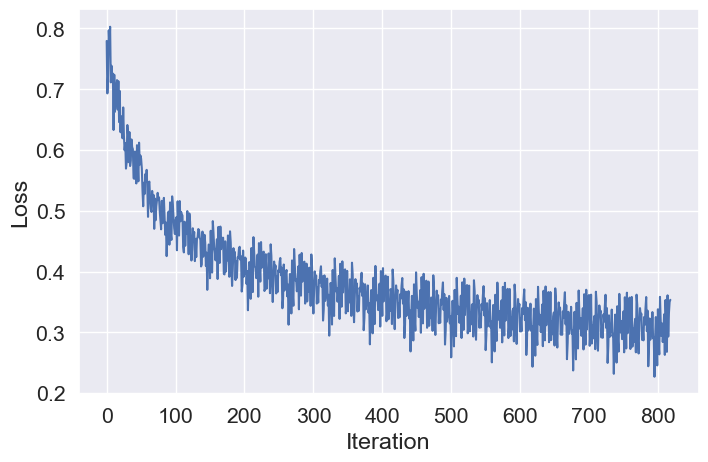

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(losses)), losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

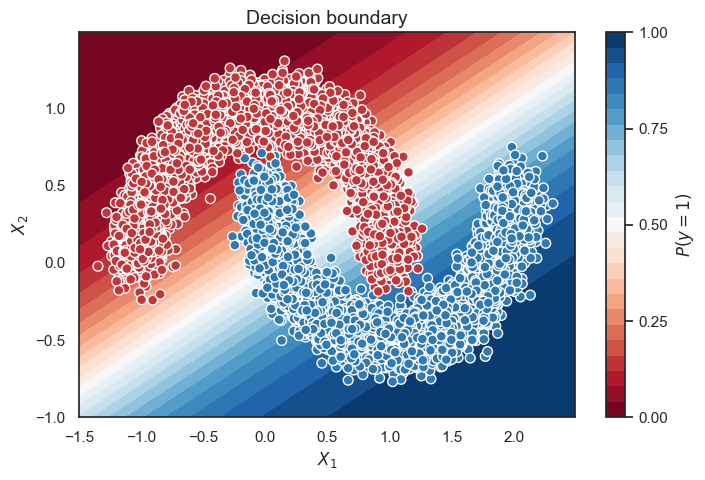

In [98]:
import numpy as np

sns.set(style="white")

xx, yy = np.mgrid[-1.5:2.5:.01, -1.:1.5:.01]
grid = np.c_[xx.ravel(), yy.ravel()]
batch = torch.from_numpy(grid).type(torch.float32)
with torch.no_grad():
    probs = torch.sigmoid(linear_regression(batch).reshape(xx.shape))
    probs = probs.numpy().reshape(xx.shape)

f, ax = plt.subplots(figsize=(8, 5))
ax.set_title("Decision boundary", fontsize=14)
contour = ax.contourf(xx, yy, probs, 25, cmap="RdBu",
                      vmin=0, vmax=1)
ax_c = f.colorbar(contour)
ax_c.set_label("$P(y = 1)$")
ax_c.set_ticks([0, .25, .5, .75, 1])

ax.scatter(X[100:, 0], X[100:, 1], c=y[100:], s=50,
           cmap="RdBu", vmin=-.2, vmax=1.2,
           edgecolor="white", linewidth=1)

ax.set(xlabel="$X_1$", ylabel="$X_2$")
plt.show()

### Задание 4. Реализуйте predict и посчитайте accuracy на test.

In [35]:
@torch.no_grad()
def predict(dataloader, model):
    model.eval()
    predictions = np.array([])
    for x_batch, _ in dataloader:
        logits = model(x_batch).flatten()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).type(torch.long)
        predictions = np.hstack((predictions, preds.numpy().flatten()))
    return predictions.flatten()

In [36]:
from sklearn.metrics import accuracy_score

In [37]:
y_pred = predict(val_dataloader, linear_regression)

# Истинные метки (нужно собрать их из test_dataloader)
y_true = np.array([])
for _, y_batch in val_dataloader:
    y_true = np.hstack((y_true, y_batch.numpy().flatten()))

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy on test set: {accuracy:.4f}")

Accuracy on test set: 0.8728


**Вопрос 3**

Какое `accuracy` получается после обучения? (ваш ответ может варьироваться в зависимости от запуска)


**Ответ:** 0.8728

# Часть 2. Датасет MNIST
Датасет MNIST содержит рукописные цифры. Загрузим датасет и создадим DataLoader-ы. Пример можно найти в семинаре по полносвязным нейронным сетям.

In [9]:
import os

root = '..\\data'

In [10]:
os.listdir(root)

['MNIST']

In [11]:
from torchvision.datasets import MNIST
from torchvision import transforms as tfs

data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

batch_size = 10
# install for train and test
train_dataset = MNIST(root, train=True, transform=data_tfs, download=True)
val_dataset = MNIST(root, train=False, transform=data_tfs, download=True)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                               num_workers=2)
valid_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                                               num_workers=2)

classes = tuple(str(i) for i in range(10))

In [12]:
image, label = train_dataset[0]
print('размерность', image.shape, label)

размерность torch.Size([1, 28, 28]) 5


In [13]:
dataloader_info(train_dataloader)

NameError: name 'dataloader_info' is not defined

## Часть 2.1. Полносвязные нейронные сети
Сначала решим MNIST с помощью полносвязной нейронной сети.

### Задание 5. Простая полносвязная нейронная сеть

Создайте полносвязную нейронную сеть с помощью класса Sequential. Сеть состоит из:
* Уплощения матрицы в вектор (nn.Flatten);
* Двух скрытых слоёв из 128 нейронов с активацией nn.ELU;
* Выходного слоя с 10 нейронами.


In [25]:
activation = nn.ELU()

In [26]:
def create_model_by_activation(f_activation=nn.ELU()):
    model = nn.Sequential(
        nn.Flatten(),  # Уплощение матрицы в вектор
        nn.Linear(in_features=28 * 28, out_features=128),
        f_activation,
        nn.Linear(in_features=128, out_features=128),
        f_activation,
        nn.Linear(in_features=128, out_features=10))
    return model

In [27]:

model = create_model_by_activation(activation)
print(model)


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ELU(alpha=1.0)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ELU(alpha=1.0)
  (5): Linear(in_features=128, out_features=10, bias=True)
)


In [28]:
count_parameters(model)

NameError: name 'count_parameters' is not defined

Задайте лосс для обучения (кросс-энтропия).

Вспомним, что такое кросс-энтропийная функция потерь:

$$
L = -\frac{1}{N} \sum_{n=1}^{N} \sum_{i=1}^{C} y_{ni} \log(\hat{y}_{ni})
$$

где:
- $N$ — количество объектов в выборке,
- $C$ — количество классов,
- $y_{ni}$ — истинная метка (one-hot представление),
- $\hat{y}_{ni}$ — предсказанная вероятность модели для класса $i$ на примере $n$.

***Пример расчета***

Рассмотрим пример расчета кросс-энтропийной функции потерь для задачи многоклассовой классификации с 10 классами. Предположим, что у нас есть один объект, истинный класс которого известен, а модель выдала свои предсказания в виде вероятностей для каждого класса.

Пусть объект является цифрой 2. Тогда:
     $$
     y = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
     $$

Пусть модель выдала следующие вероятности для 10 классов:  
     $$
     \hat{y} = [0.1, 0.05, 0.6, 0.15, 0.05, 0.02, 0.01, 0.01, 0.01, 0.0]
     $$

$$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$



Только один элемент $y_i$ равен 1, остальные равны 0. Поэтому:

$
L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i) = - y_2 \cdot log(\hat{y}_2) = - 1 \cdot log(0.6) \approx 0.51
$

### Train loop (seriously)

Давайте разберемся с кодом ниже, который подойдет для 90% задач в будущем.


```python
for epoch in range(max_epochs):  # <--------------- итерируемся по датасету несколько раз
    for k, dataloader in loaders.items():  # <----- несколько dataloader для train / valid / test
        for x_batch, y_batch in dataloader:  # <--- итерируемся по датасету. Так как мы используем SGD а не GD, то берем батчи заданного размера
            if k == "train":
                model.train()  # <------------------ переводим модель в режим train
                optimizer.zero_grad()  # <--------- обнуляем градиенты модели
                outp = model(x_batch)
                loss = criterion(outp, y_batch) # <-считаем "лосс" для логистической регрессии
                loss.backward()  # <--------------- считаем градиенты
                optimizer.step()  # <-------------- делаем шаг градиентного спуска
            else:  # <----------------------------- test/eval
                model.eval()  # <------------------ переводим модель в режим eval
                with torch.no_grad():  # <--------- НЕ считаем градиенты
                    outp = model(x_batch)  # <------------- получаем "логиты" из модели
            count_metrics(outp, y_batch)  # <-------------- считаем метрики
```

### Задание 6. Дополните цикл обучения.

In [29]:
loaders = {"train": train_dataloader, "valid": valid_dataloader}

In [30]:
list(loaders.items())

[('train', <torch.utils.data.dataloader.DataLoader at 0x15caf992600>),
 ('valid', <torch.utils.data.dataloader.DataLoader at 0x15caf8229f0>)]

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [32]:
def train_model(model, loaders, max_epochs=10):
    '''
    Обучает модель
    :param model: Модель в формате Torch
    :param loaders: Словарь загрузчиков train, valid
    :param max_epochs:
    :return: accuracy массив
    '''

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    max_epochs = max_epochs
    accuracy = {"train": [], "valid": []}
    for epoch in range(max_epochs):
        for k, dataloader in loaders.items():
            epoch_correct = 0
            epoch_all = 0

            if k == "train":
                model.train()
            else:
                model.eval()
            n_batch = 0
            for x_batch, y_batch in dataloader:
                if k == "train":
                    optimizer.zero_grad()  # Обнуляем градиенты
                    outp = model(x_batch)
                else:
                    with torch.no_grad():  # Отключаем вычисление градиентов для валидации
                        outp = model(x_batch)

                preds = outp.argmax(-1)
                correct = (preds == y_batch).sum()  # Считаем количество правильных предсказаний
                epoch_correct += correct.item()
                epoch_all += y_batch.size(0)

                if k == "train":
                    loss = criterion(outp, y_batch)  # Вычисляем потери
                    loss.backward()  # Обратный проход
                    optimizer.step()  # Обновляем веса
                n_batch += 1
                if n_batch % 1000 == 0:
                    print(f"Epoch: {epoch + 1}, Batch: {n_batch}/{len(dataloader)}, Loss: {loss.item()}")

            if k == "train":
                print(f"Epoch: {epoch + 1}")
            print(f"Loader: {k}. Accuracy: {epoch_correct / epoch_all}")
            accuracy[k].append(epoch_correct / epoch_all)
    return accuracy


In [33]:
model = create_model_by_activation()

In [34]:
accuracy = train_model(model, loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.297246515750885
Epoch: 1, Batch: 2000/6000, Loss: 0.2402469664812088
Epoch: 1, Batch: 3000/6000, Loss: 0.06375060975551605
Epoch: 1, Batch: 4000/6000, Loss: 0.08538047224283218
Epoch: 1, Batch: 5000/6000, Loss: 0.27149420976638794
Epoch: 1, Batch: 6000/6000, Loss: 0.008365195244550705
Epoch: 1
Loader: train. Accuracy: 0.91185


KeyboardInterrupt: 

In [132]:
accuracy

{'train': [0.9131333333333334,
  0.9553333333333334,
  0.96385,
  0.9694666666666667,
  0.9714,
  0.9741833333333333,
  0.97665,
  0.9774,
  0.97905,
  0.9805666666666667],
 'valid': [0.9549,
  0.952,
  0.9638,
  0.9692,
  0.9701,
  0.9718,
  0.97,
  0.9656,
  0.9696,
  0.9681]}

Проведем предсказание на одном символе - пример вывода модели на продакшн

In [133]:
valid_loader = loaders['valid']

valid_iter = iter(valid_loader)
x_batch, y_batch = next(valid_iter)
random_index = random.randint(0, len(x_batch) - 1)

random_example = x_batch[random_index]
random_label = y_batch[random_index]

print(f"Случайный пример: {random_example}")
print(f"Метка: {random_label}")

Случайный пример: tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1

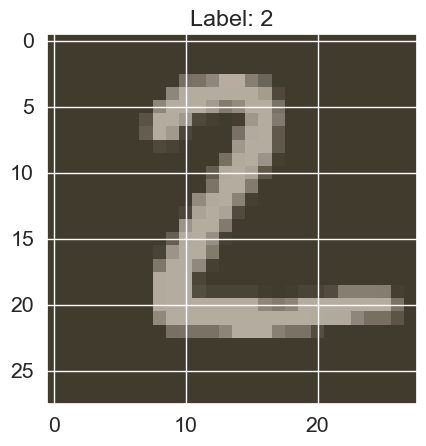

In [134]:
import matplotlib.pyplot as plt

random_example_orig = random_example.permute(1, 2, 0)
random_example = random_example_orig

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])
random_example = random_example * std + mean

random_example = random_example.numpy()
plt.imshow(random_example)
plt.title(f"Label: {random_label.item()}")
plt.show()

In [135]:
true_label = y_batch[random_index]
random_example = random_example_orig
model.eval()

with torch.no_grad():
    # Добавляем размерность батча
    random_example = random_example.unsqueeze(0)
    output = model(random_example)
    predicted_label = output.argmax(dim=1).item()

print(f"Истинная метка: {true_label.item()}")
print(f"Предсказанная метка: {predicted_label}")

Истинная метка: 2
Предсказанная метка: 2


### Задание 7. Протестируйте разные функции активации.
Попробуйте разные функции активации. Для каждой функции активации посчитайте массив validation accuracy. Лучше реализовать это в виде функции, берущей на вход активацию и получающей массив из accuracies.

Функции активации добавляют ***нелинейность в модель***, что позволяет сети решать сложные задачи, такие как классификация и регрессия. Без функций активации нейронная сеть была бы линейной моделью, так как ***композиция линейных преобразований*** это ***линейное преобразование***.

**ReLU (Rectified Linear Unit)**
   - Формула: $ f(x) = \max(0, x) $
   - Диапазон значений: $ [0, \infty) $

**Leaky ReLU**
   - Формула: $ f(x) = \max(\alpha x, x) $, где $ \alpha $ — маленькое положительное число (обычно $ \alpha = 0.01 $).
   - Диапазон значений: $ (-\infty, \infty) $

**Exponential Linear Unit (ELU)**
   - Формула:
   $f(x) = $
     \begin{cases}
     x & \text{если } x > 0 \\
     \alpha (e^x - 1) & \text{если } x \leq 0
     \end{cases}
   - Диапазон значений:  $ (-\alpha, \infty) $

**Линейная функция активации**
   - Формула: $ f(x) = x $
   - Диапазон значений: $ (-\infty, \infty) $

   Обратите внимание, что данная функция активации **не добавляет** нелинейности.

In [35]:
model_plain = create_model_by_activation(nn.Identity())
plain_accuracy=train_model(model_plain,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 1.2017462253570557
Epoch: 1, Batch: 2000/6000, Loss: 0.04682308807969093
Epoch: 1, Batch: 3000/6000, Loss: 0.7016700506210327
Epoch: 1, Batch: 4000/6000, Loss: 0.36269673705101013
Epoch: 1, Batch: 5000/6000, Loss: 0.27193352580070496
Epoch: 1, Batch: 6000/6000, Loss: 0.041884645819664
Epoch: 1
Loader: train. Accuracy: 0.85935
Epoch: 1, Batch: 1000/1000, Loss: 0.041884645819664
Loader: valid. Accuracy: 0.8733
Epoch: 2, Batch: 1000/6000, Loss: 1.0800416469573975
Epoch: 2, Batch: 2000/6000, Loss: 0.033023037016391754
Epoch: 2, Batch: 3000/6000, Loss: 0.43324199318885803
Epoch: 2, Batch: 4000/6000, Loss: 0.5165619254112244
Epoch: 2, Batch: 5000/6000, Loss: 0.5991749167442322
Epoch: 2, Batch: 6000/6000, Loss: 0.11583636701107025
Epoch: 2
Loader: train. Accuracy: 0.8892
Epoch: 2, Batch: 1000/1000, Loss: 0.11583636701107025
Loader: valid. Accuracy: 0.9042
Epoch: 3, Batch: 1000/6000, Loss: 0.1446392685174942
Epoch: 3, Batch: 2000/6000, Loss: 0.4420596659183502

In [36]:
model_ReLU = create_model_by_activation(nn.ReLU())
ReLU_accuracy=train_model(model_ReLU,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.2860991060733795
Epoch: 1, Batch: 2000/6000, Loss: 0.0803895965218544
Epoch: 1, Batch: 3000/6000, Loss: 0.047089532017707825
Epoch: 1, Batch: 4000/6000, Loss: 0.3666039705276489
Epoch: 1, Batch: 5000/6000, Loss: 0.1159403920173645
Epoch: 1, Batch: 6000/6000, Loss: 0.1564016044139862
Epoch: 1
Loader: train. Accuracy: 0.9039
Epoch: 1, Batch: 1000/1000, Loss: 0.1564016044139862
Loader: valid. Accuracy: 0.942
Epoch: 2, Batch: 1000/6000, Loss: 0.03912075608968735
Epoch: 2, Batch: 2000/6000, Loss: 0.017649894580245018
Epoch: 2, Batch: 3000/6000, Loss: 0.09136976301670074
Epoch: 2, Batch: 4000/6000, Loss: 0.06607306003570557
Epoch: 2, Batch: 5000/6000, Loss: 0.3316746652126312
Epoch: 2, Batch: 6000/6000, Loss: 0.15764731168746948
Epoch: 2
Loader: train. Accuracy: 0.9498666666666666
Epoch: 2, Batch: 1000/1000, Loss: 0.15764731168746948
Loader: valid. Accuracy: 0.9566
Epoch: 3, Batch: 1000/6000, Loss: 0.07385437190532684
Epoch: 3, Batch: 2000/6000, Loss: 0.10

In [37]:
model_LeakyReLU = create_model_by_activation(nn.LeakyReLU())
LeakyReLU_accuracy=train_model(model_LeakyReLU,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.5473178625106812
Epoch: 1, Batch: 2000/6000, Loss: 0.1716153621673584
Epoch: 1, Batch: 3000/6000, Loss: 0.043726492673158646
Epoch: 1, Batch: 4000/6000, Loss: 0.097885861992836
Epoch: 1, Batch: 5000/6000, Loss: 0.011245454661548138
Epoch: 1, Batch: 6000/6000, Loss: 0.019425703212618828
Epoch: 1
Loader: train. Accuracy: 0.9068333333333334
Epoch: 1, Batch: 1000/1000, Loss: 0.019425703212618828
Loader: valid. Accuracy: 0.9512
Epoch: 2, Batch: 1000/6000, Loss: 0.20977099239826202
Epoch: 2, Batch: 2000/6000, Loss: 0.005940108560025692
Epoch: 2, Batch: 3000/6000, Loss: 0.5711542367935181
Epoch: 2, Batch: 4000/6000, Loss: 0.07334401458501816
Epoch: 2, Batch: 5000/6000, Loss: 0.8691821098327637
Epoch: 2, Batch: 6000/6000, Loss: 0.015553280711174011
Epoch: 2
Loader: train. Accuracy: 0.95215
Epoch: 2, Batch: 1000/1000, Loss: 0.015553280711174011
Loader: valid. Accuracy: 0.9608
Epoch: 3, Batch: 1000/6000, Loss: 0.23984065651893616
Epoch: 3, Batch: 2000/6000, Lo

In [38]:
model_ELU = create_model_by_activation(nn.ELU())
ELU_accuracy=train_model(model_ELU,loaders, 10)

Epoch: 1, Batch: 1000/6000, Loss: 0.14851363003253937
Epoch: 1, Batch: 2000/6000, Loss: 0.04764143377542496
Epoch: 1, Batch: 3000/6000, Loss: 0.18519899249076843
Epoch: 1, Batch: 4000/6000, Loss: 0.4835026264190674
Epoch: 1, Batch: 5000/6000, Loss: 0.042063333094120026
Epoch: 1, Batch: 6000/6000, Loss: 0.01827838458120823
Epoch: 1
Loader: train. Accuracy: 0.9146166666666666
Epoch: 1, Batch: 1000/1000, Loss: 0.01827838458120823
Loader: valid. Accuracy: 0.9483
Epoch: 2, Batch: 1000/6000, Loss: 0.018110794946551323
Epoch: 2, Batch: 2000/6000, Loss: 0.029356399551033974
Epoch: 2, Batch: 3000/6000, Loss: 0.4516476094722748
Epoch: 2, Batch: 4000/6000, Loss: 0.02392340451478958
Epoch: 2, Batch: 5000/6000, Loss: 0.03964082896709442
Epoch: 2, Batch: 6000/6000, Loss: 0.2397640496492386
Epoch: 2
Loader: train. Accuracy: 0.9545166666666667
Epoch: 2, Batch: 1000/1000, Loss: 0.2397640496492386
Loader: valid. Accuracy: 0.9613
Epoch: 3, Batch: 1000/6000, Loss: 0.04665582999587059
Epoch: 3, Batch: 2000

### Accuracy
Построим график accuracy/epoch для каждой функции активации.

In [39]:
max_epochs = 10

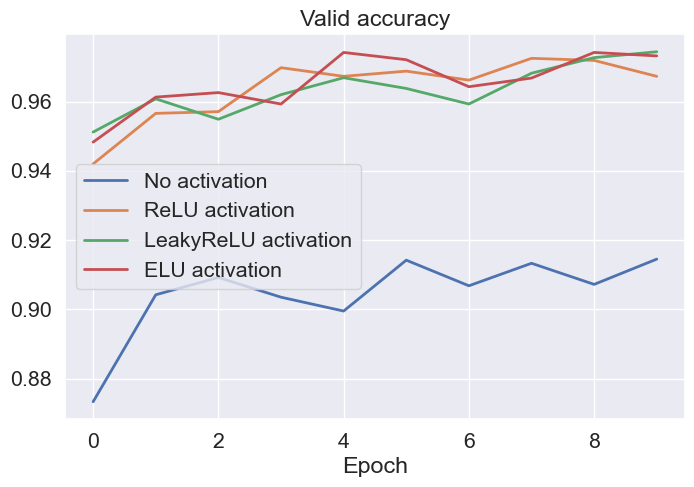

In [40]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(8, 5))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy['valid'], label="No activation", linewidth=2)
plt.plot(range(max_epochs), ReLU_accuracy['valid'], label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), LeakyReLU_accuracy['valid'], label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), ELU_accuracy['valid'], label="ELU activation", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

In [35]:
ReLU_accuracy['valid']

[0.9723, 0.968, 0.9738, 0.9742, 0.9687, 0.9718, 0.9706, 0.9709, 0.9732, 0.9737]

**Вопрос 4.** Какая из активаций показала наивысший `accuracy` к концу обучения?

**Ответ:** наивысший `accuracy` к концу обучения показала ReLU - 0,9737

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

## Часть 2.2 Сверточные нейронные сети

### Ядра
Сначала немного поработам с самим понятием ядра свёртки.

In [ ]:
!dir

In [ ]:
!wget https://img.the-village.kz/the-village.com.kz/post-cover/5x5-I6oiwjmq79dMCZMEbA-default.jpg -O sample_photo.jpg

In [104]:
import cv2

sns.set(style="white")
img = cv2.imread("sample_photo.jpg")
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

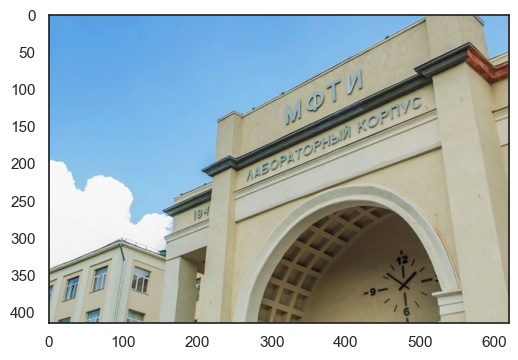

In [106]:
plt.figure(figsize=(6, 4))
plt.imshow(RGB_img)
plt.show()

Попробуйте посмотреть как различные свертки влияют на фото. Например, попробуйте
A)
```
[0, 0, 0],
[0, 1, 0],
[0, 0, 0]
```
Б)
```
[0, 1, 0],
[0, -2, 0],
[0, 1, 0]
```
В)
```
[0, 0, 0],
[1, -2, 1],
[0, 0, 0]
```
Г)
```
[0, 1, 0],
[1, -4, 1],
[0, 1, 0]
```
Д)
```
[0, -1, 0],
[-1, 5, -1],
[0, -1, 0]
```
Е)
```
[0.0625, 0.125, 0.0625],
[0.125, 0.25, 0.125],
[0.0625, 0.125, 0.0625]
```

Не стесняйтесь пробовать свои варианты!

In [110]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F


In [111]:
conv_1 = np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]])  # A
conv_2 = np.array([[0, 1, 0], [0, -2, 0], [0, 1, 0]])  # Б
conv_3 = np.array([[0, 0, 0], [1, -2, 1], [0, 0, 0]])  # В
conv_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])  # Г
conv_5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])  # Д
conv_6 = np.array([[0.0625, 0.125, 0.0625], [0.125, 0.25, 0.125], [0.0625, 0.125, 0.0625]])  # E

In [112]:
conv = dict(А=conv_1, Б=conv_2, В=conv_3, Г=conv_4, Д=conv_5, Е=conv_6)

In [113]:
def image_cnn(image, conv):
    '''
    Функция преобразования изображения ядром свертки
    :param image: изображение
    :param conv: ядро
    :return: изображение
    '''
    global img_t, kernel, result
    RGB_img = image
    img_t = torch.from_numpy(RGB_img).type(torch.float32).unsqueeze(0)
    kernel = torch.tensor(conv).reshape(1, 1, 3, 3).type(torch.float32)
    kernel = kernel.repeat(3, 3, 1, 1)
    img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
    img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size
    result = F.conv2d(img_t, kernel)[0]
    return result.permute(1, 2, 0).numpy() / 256 / 3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79296875..1.0351562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76692706..0.81901044].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1679688..1.4140625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2005209..2.0546875].


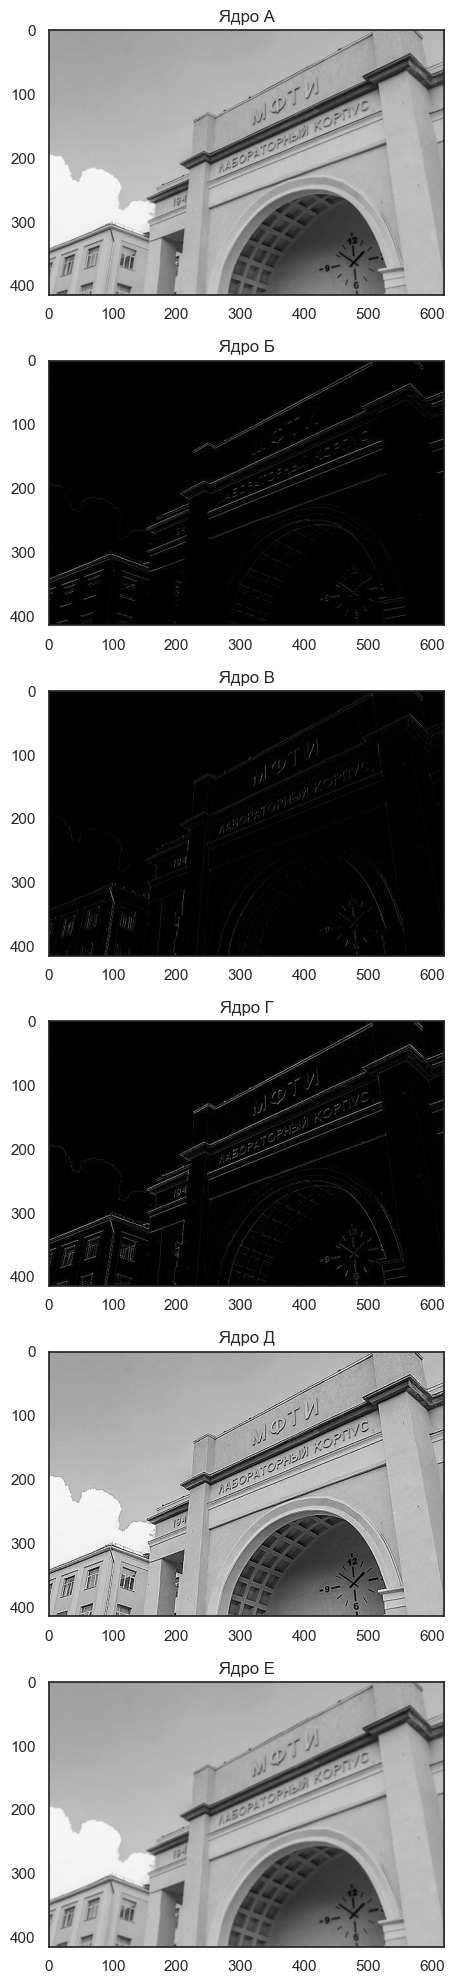

In [115]:
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(300, 20))

for ax, (key, value) in zip(axes.flatten(), conv.items()):

    ax.imshow(image_cnn(RGB_img,conv[key]))
    ax.set_title(f'Ядро {key}')

for ax in axes.flatten()[len(conv):]:
    ax.axis('off')

plt.tight_layout()

plt.show()

**Вопрос 5.** Как можно описать действия ядер, приведенных выше? Сопоставьте для каждой буквы число.

**Ответ:**
1) Размытие  **Е**
2) Увеличение резкости **Д**

3) Тождественное преобразование **А**

4) Выделение вертикальных границ **B**

5) Выделение горизонтальных границ **Б**

6) Выделение границ **Г**


### Задание 8. Реализуйте LeNet

Если мы сделаем параметры сверток обучаемыми, то можем добиться хороших результатов для задач компьютерного зрения. Реализуйте архитектуру LeNet, предложенную еще в 1998 году!
На этот раз используйте модульную структуру (без помощи класса Sequential).

Наша нейронная сеть будет состоять из
* Свёртки 3x3 (1 карта на входе, 6 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Свёртки 3x3 (6 карт на входе, 16 на выходе) с активацией ReLU;
* MaxPooling-а 2x2;
* Уплощения (nn.Flatten);
* Полносвязного слоя со 120 нейронами и активацией ReLU;
* Полносвязного слоя с 84 нейронами и активацией ReLU;
* Выходного слоя из 10 нейронов.




In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=3)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=3)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5x5 - размер после пуллинг
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))         # активация ReLU
        x = F.max_pool2d(x, 2)        # MaxPooling 2x2
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))   # полносвязный слой
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Создаем экземпляр сети
net = LeNet()
print(net)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [57]:
count_parameters(net)

conv1.weight: 54 параметров
conv1.bias: 6 параметров
conv2.weight: 864 параметров
conv2.bias: 16 параметров
fc1.weight: 48000 параметров
fc1.bias: 120 параметров
fc2.weight: 10080 параметров
fc2.bias: 84 параметров
fc3.weight: 840 параметров
fc3.bias: 10 параметров
итого: 60074 параметров


In [142]:
from torchsummary import summary
summary(net, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 26, 26]              60
            Conv2d-2           [-1, 16, 11, 11]             880
           Flatten-3                  [-1, 400]               0
            Linear-4                  [-1, 120]          48,120
            Linear-5                   [-1, 84]          10,164
            Linear-6                   [-1, 10]             850
Total params: 60,074
Trainable params: 60,074
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.23
Estimated Total Size (MB): 0.28
----------------------------------------------------------------


In [67]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [68]:
model = LeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

loaders = {"train": train_dataloader, "valid": valid_dataloader}

### Задание 9. Обучите CNN
Используйте код обучения, который вы написали для полносвязной нейронной сети.

In [69]:
lenet_accuracy = train_model(net, loaders, max_epochs=10)

Epoch: 1, Batch: 1000/6000, Loss: 3.421265546421637e-06
Epoch: 1, Batch: 2000/6000, Loss: 1.4305103945844166e-07
Epoch: 1, Batch: 3000/6000, Loss: 9.059869512384466e-07
Epoch: 1, Batch: 4000/6000, Loss: 4.637157871911768e-06
Epoch: 1, Batch: 5000/6000, Loss: 1.1920926823449918e-07
Epoch: 1, Batch: 6000/6000, Loss: 0.022587474435567856
Epoch: 1
Loader: train. Accuracy: 0.996
Epoch: 1, Batch: 1000/1000, Loss: 0.022587474435567856
Loader: valid. Accuracy: 0.9887
Epoch: 2, Batch: 1000/6000, Loss: 2.3841842278216063e-07
Epoch: 2, Batch: 2000/6000, Loss: 3.6954810411771177e-07
Epoch: 2, Batch: 3000/6000, Loss: 0.0
Epoch: 2, Batch: 4000/6000, Loss: 8.293534483527765e-05
Epoch: 2, Batch: 5000/6000, Loss: 2.384183090953229e-07
Epoch: 2, Batch: 6000/6000, Loss: 0.0016625563148409128
Epoch: 2
Loader: train. Accuracy: 0.9970833333333333
Epoch: 2, Batch: 1000/1000, Loss: 0.0016625563148409128
Loader: valid. Accuracy: 0.9891
Epoch: 3, Batch: 1000/6000, Loss: 1.1181211448274553e-05
Epoch: 3, Batch: 2

Сравним с предыдущем пунктом

In [70]:
max_epochs = 10

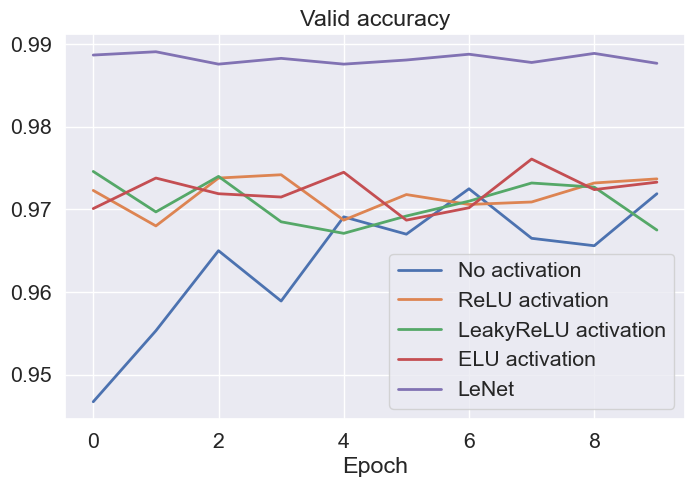

In [116]:
sns.set(style="darkgrid", font_scale=1.4)

plt.figure(figsize=(8, 5))
plt.title("Valid accuracy")
plt.plot(range(max_epochs), plain_accuracy['valid'], label="No activation", linewidth=2)
plt.plot(range(max_epochs), ReLU_accuracy['valid'], label="ReLU activation", linewidth=2)
plt.plot(range(max_epochs), LeakyReLU_accuracy['valid'], label="LeakyReLU activation", linewidth=2)
plt.plot(range(max_epochs), ELU_accuracy['valid'], label="ELU activation", linewidth=2)
plt.plot(range(max_epochs), lenet_accuracy['valid'], label="LeNet", linewidth=2)
plt.legend()
plt.xlabel("Epoch")
plt.show()

**Вопрос 6**
Какое `accuracy` получается после обучения с точностью до двух знаков после запятой?

**Ответ:** **0,99**